# Día 1 — EDA del dataset crudo (fintech banking)

**Contexto.** El dataset llega desde S3 como un único archivo JSON. Antes de diseñar Bronze → Silver → Gold, el primer paso es entender qué hay realmente adentro: schema, calidad, duplicados, formatos, anomalías. Este notebook documenta esa exploración y deja por escrito los hallazgos que después guían las decisiones de modelado.

**Lo que va a quedar claro al final del notebook:**

1. **Schema real vs. consigna.** Comprobar que los 5.000 records prometidos están, que las 24 keys top-level son uniformes, y que las divergencias con la spec están identificadas y documentadas.
2. **Calidad de datos.** Detectar las tres formas en que el generador ensucia los datos: casing/idioma inconsistente, nulls codificados como strings, formatos numéricos y de fecha mezclados.
3. **Duplicación.** Confirmar la hipótesis de que los duplicados en los arrays anidados (`accounts`, `transactions`, `loans`) son 100% derivados de duplicados en `customers`, y que dedup en customers cascadea limpieza a todo el resto.
4. **Decisiones derivadas.** Cada hallazgo concreto deja una decisión registrada (qué se limpia en Spark, qué en dbt, qué se imputa, qué se preserva como NULL).

Las decisiones se vuelcan después a `docs/decisions.md` para que vivan fuera del notebook.

---

## Sección 0 — Setup

Imports y configuración global. Se usa `pandas` para análisis exploratorio porque el dataset es chico (~5k records, manejable en memoria). Spark entra recién en Silver, donde el paralelismo y el manejo de arrays anidados a escala empiezan a aportar.

In [1]:
import json
import re
import itertools
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display: ver columnas completas, sin truncado, en cells anchas
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

# Path al raw JSON descargado de S3.
# El assert es defensivo: si el archivo no está, el notebook falla rápido
# con un mensaje claro en lugar de un IOError críptico más adelante.
RAW_PATH = Path("../data/raw/fintech_banking_dataset.json")
assert RAW_PATH.exists(), f"No se encuentra el dataset en {RAW_PATH.resolve()}"

print(f"Archivo: {RAW_PATH.resolve()}")
print(f"Tamaño:  {RAW_PATH.stat().st_size / 1024 / 1024:.2f} MB")

C:\Users\alexi\AppData\Local\Temp\ipykernel_16844\2025435447.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Archivo: C:\Users\alexi\OneDrive - Universidad Católica del Uruguay\Desktop\qversity-data-2026-montevideo-alexiaurrecochea\data\raw\fintech_banking_dataset.json
Tamaño:  49.13 MB


---

## Sección 1 — Carga y forma global

Cargamos el JSON entero en memoria y verificamos su forma macro: ¿es una lista? ¿cuántos records hay? ¿qué keys aparecen en el primer record? Esto define el universo sobre el que después construimos las dimensiones.

In [2]:
# Cargamos el JSON completo en memoria. Es viable porque el archivo es
# chico (~5k customers ≈ 110 MB). Si fuera ≥1 GB convendría streaming
# (ijson o spark.read.json directo) — para este volumen, json.load es
# más simple y rápido.
with open(RAW_PATH, encoding="utf-8") as f:
    data = json.load(f)

print(f"Tipo de la raíz:        {type(data).__name__}")
print(f"Cantidad de records:    {len(data) if isinstance(data, list) else 'no es una lista'}")
print(f"\nKeys del primer record:")
for k in data[0].keys():
    print(f"  - {k}")

Tipo de la raíz:        list
Cantidad de records:    5100

Keys del primer record:
  - customer_id
  - first_name
  - last_name
  - email
  - phone_number
  - date_of_birth
  - gender
  - nationality
  - city
  - country
  - address
  - lat
  - lon
  - registration_date
  - kyc_status
  - risk_score
  - customer_segment
  - relationship_manager
  - status
  - accounts
  - transactions
  - loans
  - credit_info
  - digital_engagement


---

## Sección 2 — Schema real vs. documentado

La consigna lista las keys esperadas y sus tipos. Antes de confiar en cualquier asunción, comprobamos dos cosas concretas:

1. **Qué tipo tiene cada campo en el primer record** (plano, lista, dict). Esto define qué se aplana en Spark vs. qué se deja para dbt.
2. **Si TODOS los records comparten el mismo schema top-level** o si hay records con campos extra/faltantes (lo cual obligaría a usar `explode_outer` y manejo defensivo de NULLs).

In [3]:
# Inspeccionamos el schema real del primer record para tener una vista
# rápida de qué tipo es cada campo. Distinguimos 3 categorías:
#   - planos (string, int, bool, date): van directos a dim_customer
#   - lists (accounts, transactions, loans): se aplanan con Spark explode
#   - dicts (credit_info, digital_engagement): se aplanan en dbt con jsonb operators
sample = data[0]
print(f"{'Campo':30s} {'Tipo':30s} {'Sample value'}")
print("-" * 100)
for k, v in sample.items():
    if isinstance(v, list):
        sub = type(v[0]).__name__ if v else "empty"
        t = f"list[{sub}] (len={len(v)})"
        sval = f"{len(v)} items"
    elif isinstance(v, dict):
        t = f"dict (keys={len(v)})"
        sval = list(v.keys())
    else:
        t = type(v).__name__
        sval = str(v)[:50]
    print(f"{k:30s} {t:30s} {sval}")

Campo                          Tipo                           Sample value
----------------------------------------------------------------------------------------------------
customer_id                    str                            CUST-0004655
first_name                     str                            Lucas
last_name                      str                            Brito
email                          str                            lucas.brito@gmail.com
phone_number                   str                            +569611566924
date_of_birth                  str                            1975-01-11
gender                         str                            F
nationality                    str                            CL
city                           str                            La Serna
country                        str                            CL
address                        str                            Pasaje Bolivia 637 Interior 460, Nueva Côte d'Ivoi
la

In [4]:
# Crítico: ¿todos los records tienen las mismas keys top-level?
# Si no, el pipeline tiene que ser más defensivo (manejar campos opcionales).
# Si sí, podemos asumir schema uniforme y simplificar la lectura.
all_keys = [set(r.keys()) for r in data]
unique_keysets = {frozenset(ks) for ks in all_keys}
print(f"Cantidad de schemas top-level distintos: {len(unique_keysets)}")

if len(unique_keysets) > 1:
    print("⚠️ Hay records con keys distintas. Inspeccionar diferencias:")
    base = max(unique_keysets, key=len)
    for ks in unique_keysets:
        if ks != base:
            print(f"  Faltantes vs base: {base - ks}")
            print(f"  Extras vs base:    {ks - base}")
else:
    print("✓ Schema uniforme: las 24 keys aparecen en los 5.000 records.")

Cantidad de schemas top-level distintos: 1
✓ Schema uniforme: las 24 keys aparecen en los 5.000 records.


**Hallazgo Sección 2.** Schema top-level uniforme: 24 keys idénticas en los 5.000 records. No hace falta lógica defensiva para campos faltantes a nivel root. La complejidad real está adentro de los nested arrays (`accounts`, `transactions`, `loans`) y los nested objects (`credit_info`, `digital_engagement`), que tratamos en secciones más adelante.

---

## Sección 3 — Customer: campos planos

Empezamos por la parte más simple: los campos planos a nivel customer (sin arrays ni dicts anidados). Aquí buscamos:

- **Nulls reales vs. nulls encubiertos** (strings como `"null"`, `"N/A"` que parsers automáticos no detectan).
- **Inconsistencias categóricas** (casing chaos, traducciones al español mezcladas con inglés).
- **Formatos de fecha** (¿hay uno solo o varios coexistentes? ¿es ambiguo el orden día/mes?).
- **Duplicación de customer_id** (la PK natural de toda la jerarquía).

In [5]:
# Aislamos los campos planos: ni listas ni diccionarios.
# Esto nos da el DataFrame base de customer que después se transforma
# en dim_customer en Silver.
flat_keys = [k for k, v in sample.items() if not isinstance(v, (list, dict))]
df_customers = pd.DataFrame([{k: r.get(k) for k in flat_keys} for r in data])

print(f"Shape: {df_customers.shape}")
df_customers.head()

Shape: (5100, 19)


,customer_id,first_name,last_name,email,phone_number,date_of_birth,gender,nationality,city,country,address,lat,lon,registration_date,kyc_status,risk_score,customer_segment,relationship_manager,status
0,CUST-0004655,Lucas,Brito,lucas.brito@gmail.com,+569611566924,1975-01-11,F,CL,La Serna,CL,"Pasaje Bolivia 637 Interior 460, Nueva Côte d'...",-18.551408,-69.638686,12-21-2025,EXPIRED,68.06,retail,Luis Hernandez,suspended
1,CUST-0003828,Oliver,Montalbán,oliver.montalbán@bol.com.br,+552104315410,1960-11-15,M,BR,Salvador,BR,"Av. carrera 5ª # 12-48 Sur, Casa 55, 054138, R...",-4.476765,-68.027337,2023-05-09,rejected,36.10,private_banking,Sofia Lopez,inactive
2,CUST-0004334,Matilda,Olivé,matilda.olivé@gmail.com,(+57) 6221127245,1969-04-04,Other,CO,Medellin,CO,"Dg. 9U # 6-8 Sur, Bodega 108, 258646, Tocancip...",8.009853,-73.370236,2025-03-19,EXPIRED,22.68,retail,Valentina Torres,suspended
3,CUST-0003684,Armando,Villalba,armando.villalba@hotmail.com,(+598) 0828202059,1999-09-24,F,UY,Montevideo,UY,"Diagonal 86 # 14-83, Apartamento 84, 180490, B...",-32.711033,-57.194272,2025-02-12,pending,78.46,sme,Ana Martinez,inactive
4,CUST-0004453,Jade,Camargo,jade.camargo@hotmail.com,+566194931724,1961-09-11,M,CL,Temuco,CL,"Avenida Omar Nuñez N° 454 Dto. 2, Comodoro Riv...",-35.219252,-69.762767,2026-01-29,expired,34.25,private_banking,Valentina Torres,inactive


In [6]:
# Tipos detectados por pandas. Atención a las columnas 'object':
# en pandas, 'object' = string Python, pero también podría ocultar mixtos
# (ej. una columna mayormente numérica con algunos strings sucios).
df_customers.dtypes

customer_id              object
first_name               object
last_name                object
email                    object
phone_number             object
date_of_birth            object
gender                   object
nationality              object
city                     object
country                  object
address                  object
lat                     float64
lon                     float64
registration_date        object
kyc_status               object
risk_score              float64
customer_segment         object
relationship_manager     object
status                   object
dtype: object

### 3.1 Nulls reales y nulls "encubiertos"

Pandas detecta NaN automáticamente. Pero los generadores de datos sucios típicamente codifican ausencia como strings: `"null"`, `"N/A"`, `"None"`, `""`, espacios en blanco. Si no los normalizamos a NaN real, los conteos de nulls quedan sub-estimados y los valores siguen "presentes" en `value_counts`.

In [7]:
# Conteo de nulls según pandas (solo NaN reales).
# Esto es el piso del análisis — los nulls encubiertos están abajo.
nulls = df_customers.isna().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df_customers) * 100).round(2)
pd.DataFrame({"nulls": nulls, "pct": nulls_pct}).query("nulls > 0")

,nulls,pct
relationship_manager,114,2.24
address,78,1.53
gender,48,0.94


In [8]:
# Definimos un set de tokens que en este dataset representan ausencia
# pero llegan como strings. Aplicamos un map a todas las columnas object
# para convertirlos a NaN real.
NULL_TOKENS = {"null", "n/a", "na", "none", "", " "}

def normalize_nulls(s):
    """Convierte strings que son tokens de null a NaN real.
    Preserva los NaN reales y los valores no-string sin cambios.
    """
    if pd.isna(s):
        return s
    if isinstance(s, str) and s.strip().lower() in NULL_TOKENS:
        return None
    return s

# Aplicamos a todas las columnas tipo object (donde pueden haber strings sucios)
df_customers_clean = df_customers.copy()
for col in df_customers_clean.select_dtypes(include="object").columns:
    df_customers_clean[col] = df_customers_clean[col].map(normalize_nulls)

# Re-contar nulls AHORA SÍ (incluye los encubiertos).
# La diferencia con la celda anterior es el tamaño del problema real.
nulls_real = df_customers_clean.isna().sum().sort_values(ascending=False)
nulls_pct_real = (nulls_real / len(df_customers_clean) * 100).round(2)
print("Nulls REALES (incluye strings 'null'/'N/A'/''/'None'):")
print(pd.DataFrame({"nulls": nulls_real, "pct": nulls_pct_real}).query("nulls > 0"))

Nulls REALES (incluye strings 'null'/'N/A'/''/'None'):
                      nulls   pct
relationship_manager    504  9.88
address                 397  7.78
gender                  277  5.43


### 3.2 Formatos de fecha

Las fechas son uno de los puntos más comunes de error en datasets sucios. Si pandas no parsea, hay que entender por qué antes de coercitar. Empezamos mirando la materia prima sin procesar.

In [9]:
# Leemos las fechas como strings crudos para inspeccionar formatos.
# NUNCA usamos pd.to_datetime al principio: oculta el problema porque
# convierte lo que puede y NULL-ea el resto silenciosamente.
raw_reg_dates = pd.Series([r.get("registration_date") for r in data])
raw_dob = pd.Series([r.get("date_of_birth") for r in data])

print("=== registration_date — muestra de valores crudos ===")
print(raw_reg_dates.dropna().sample(20, random_state=42).tolist())

print("\n=== date_of_birth — muestra de valores crudos ===")
print(raw_dob.dropna().sample(20, random_state=42).tolist())


def detect_format(s):
    """Clasifica un valor de fecha según su patrón regex.
    Esto nos dice cuántos formatos coexisten en una sola columna.
    """
    if pd.isna(s) or s is None:
        return "null"
    if not isinstance(s, str):
        return f"non_string({type(s).__name__})"
    s = s.strip()
    if s.lower() in {"null", "n/a", "na", "none", ""}:
        return "null_token"

    # Patrones de fecha comunes
    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):    return "YYYY-MM-DD (ISO)"
    if re.match(r"^\d{8}$", s):                 return "YYYYMMDD (compacto)"
    if re.match(r"^\d{2}-\d{2}-\d{4}$", s):    return "NN-NN-YYYY (ambiguo)"
    if re.match(r"^\d{2}/\d{2}/\d{4}$", s):    return "NN/NN/YYYY (ambiguo)"
    if re.match(r"^\d{4}/\d{2}/\d{2}$", s):    return "YYYY/MM/DD"
    return f"otro: {s[:20]}"

print("\n=== Formatos detectados — registration_date ===")
print(raw_reg_dates.map(detect_format).value_counts())

print("\n=== Formatos detectados — date_of_birth ===")
print(raw_dob.map(detect_format).value_counts())

=== registration_date — muestra de valores crudos ===
['2022-06-07', '2022-09-03', '2022-11-01', '2024-06-25', '2024-09-15', '20260226', '2023-04-11', '08-18-2025', '2024-09-13', '2023-09-28', '20250523', '2024-09-08', '2020-11-15', '2024-10-30', '2020-08-19', '2022-05-02', '2021-11-04', '2023-06-30', '2020-11-20', '2021-01-17']

=== date_of_birth — muestra de valores crudos ===
['1960-09-19', '1966-08-21', '1961-05-02', '1991-03-31', '2004-11-29', '1956-11-30', '1986-10-18', '1956-12-13', '2004-12-01', '1976-01-10', '1991-06-16', '2000-09-29', '1996-01-20', '1990-07-08', '1968-05-05', '1984-10-27', '1993-11-09', '1987-01-24', '1967-09-06', '1962-06-15']

=== Formatos detectados — registration_date ===
YYYY-MM-DD (ISO)        4172
NN/NN/YYYY (ambiguo)     314
YYYYMMDD (compacto)      311
NN-NN-YYYY (ambiguo)     303
Name: count, dtype: int64

=== Formatos detectados — date_of_birth ===
YYYY-MM-DD (ISO)        4184
NN/NN/YYYY (ambiguo)     317
YYYYMMDD (compacto)      304
NN-NN-YYYY (am

Aparecen **4 formatos coexistentes** en cada columna de fecha. Dos son inequívocos (ISO `YYYY-MM-DD` y compacto `YYYYMMDD`), pero los otros dos son ambiguos: con el patrón `NN-NN-YYYY` o `NN/NN/YYYY` no podemos saber a priori si los primeros dos dígitos son día o mes.

Para resolverlo aprovechamos una propiedad estadística: **si el formato fuera DD/MM, el primer número podría ser > 12 en algunos casos** (ej. día 25). **Si fuera MM/DD, el segundo número podría ser > 12**. Si solo uno de los dos comportamientos aparece, el formato queda determinado.

In [10]:
def categorize_separator_format(s):
    """Para fechas con / o - de patrón NN-NN-YYYY, retorna la tupla
    (a, b, year) donde a y b son los primeros dos números.
    Devuelve None si la cadena no matchea ese patrón.
    """
    if not isinstance(s, str):
        return None
    s = s.strip()
    m = re.match(r"^(\d{2})[-/](\d{2})[-/](\d{4})$", s)
    if not m:
        return None
    return (int(m.group(1)), int(m.group(2)), int(m.group(3)))

parsed_reg = [p for p in (categorize_separator_format(s) for s in raw_reg_dates) if p]
parsed_dob = [p for p in (categorize_separator_format(s) for s in raw_dob) if p]


def diagnose(parsed, name):
    """Para una lista de tuplas (a, b, year), determina si el orden
    es DD/MM o MM/DD aprovechando que día puede ser > 12 pero mes no."""
    print(f"\n=== {name} — fechas patrón NN-NN-YYYY (n={len(parsed)}) ===")
    first_gt_12 = sum(1 for a, b, _ in parsed if a > 12)
    second_gt_12 = sum(1 for a, b, _ in parsed if b > 12)
    both_le_12 = sum(1 for a, b, _ in parsed if a <= 12 and b <= 12)

    print(f"  Primero > 12 (forzosamente DD): {first_gt_12}")
    print(f"  Segundo > 12 (forzosamente MM): {second_gt_12}")
    print(f"  Ambiguos (ambos ≤ 12):          {both_le_12}")

    if first_gt_12 > 0 and second_gt_12 == 0:
        print("  → DD/MM/YYYY (o DD-MM-YYYY)")
    elif second_gt_12 > 0 and first_gt_12 == 0:
        print("  → MM/DD/YYYY (o MM-DD-YYYY)")
    elif first_gt_12 > 0 and second_gt_12 > 0:
        print("  → ⚠️ MEZCLA: hay fechas DD/MM Y MM/DD en la MISMA columna")
    else:
        print("  → Sin diagnóstico claro (todas ambiguas)")

diagnose(parsed_reg, "registration_date")
diagnose(parsed_dob, "date_of_birth")


=== registration_date — fechas patrón NN-NN-YYYY (n=617) ===
  Primero > 12 (forzosamente DD): 194
  Segundo > 12 (forzosamente MM): 183
  Ambiguos (ambos ≤ 12):          240
  → ⚠️ MEZCLA: hay fechas DD/MM Y MM/DD en la MISMA columna

=== date_of_birth — fechas patrón NN-NN-YYYY (n=612) ===
  Primero > 12 (forzosamente DD): 178
  Segundo > 12 (forzosamente MM): 165
  Ambiguos (ambos ≤ 12):          269
  → ⚠️ MEZCLA: hay fechas DD/MM Y MM/DD en la MISMA columna


El diagnóstico anterior mezcla los dos separadores (`/` y `-`). Si los hay ambos, conviene separarlos: tal vez el generador uso `/` para DD/MM (formato latino) y `-` para MM-DD (formato US), y al mirarlos juntos parece ambiguo.

In [11]:
def split_separator_format(s):
    """Divide las fechas NN-NN-YYYY o NN/NN/YYYY según el separador.
    Retorna (separador, a, b, year) o None."""
    if not isinstance(s, str):
        return None
    s = s.strip()
    m = re.match(r"^(\d{2})([-/])(\d{2})[-/](\d{4})$", s)
    if not m:
        return None
    return (m.group(2), int(m.group(1)), int(m.group(3)), int(m.group(4)))

parsed_reg_sep = [p for p in (split_separator_format(s) for s in raw_reg_dates) if p]

# Diagnosticamos cada separador por separado.
# Si los dos dan diagnósticos distintos, confirmamos la hipótesis
# de que el separador desambigua el orden.
for sep_filter in ["-", "/"]:
    subset = [(a, b, y) for s, a, b, y in parsed_reg_sep if s == sep_filter]
    first_gt_12 = sum(1 for a, b, _ in subset if a > 12)
    second_gt_12 = sum(1 for a, b, _ in subset if b > 12)
    both_le_12 = sum(1 for a, b, _ in subset if a <= 12 and b <= 12)

    print(f"\n=== Separador '{sep_filter}' (n={len(subset)}) ===")
    print(f"  Primero > 12 (DD forzoso):  {first_gt_12}")
    print(f"  Segundo > 12 (MM forzoso):  {second_gt_12}")
    print(f"  Ambiguos (ambos ≤ 12):       {both_le_12}")
    if first_gt_12 > 0 and second_gt_12 == 0:
        print(f"  → '{sep_filter}' implica DD{sep_filter}MM{sep_filter}YYYY (formato latino)")
    elif second_gt_12 > 0 and first_gt_12 == 0:
        print(f"  → '{sep_filter}' implica MM{sep_filter}DD{sep_filter}YYYY (formato US)")
    else:
        print(f"  → '{sep_filter}' está mezclado también")


=== Separador '-' (n=303) ===
  Primero > 12 (DD forzoso):  0
  Segundo > 12 (MM forzoso):  183
  Ambiguos (ambos ≤ 12):       120
  → '-' implica MM-DD-YYYY (formato US)

=== Separador '/' (n=314) ===
  Primero > 12 (DD forzoso):  194
  Segundo > 12 (MM forzoso):  0
  Ambiguos (ambos ≤ 12):       120
  → '/' implica DD/MM/YYYY (formato latino)


**Hallazgo crítico Sección 3.2.** El **separador desambigua el orden**: `/` siempre es DD/MM/YYYY (latino) y `-` siempre es MM-DD-YYYY (US). Eso convierte un dataset aparentemente ambiguo en **100% recuperable** con una cascada de parsing en orden correcto (ver decisions.md §3).

### 3.3 Distribuciones categóricas críticas

Acá descubrimos el segundo gran patrón de calidad del generador: **caos de casing + traducciones mezcladas al español**. Esto va a ser un patrón estructural que se repite en TODOS los campos categóricos del dataset (lo verificaremos más adelante en las secciones de accounts/transactions/loans).

In [12]:
# Las columnas categóricas más relevantes para el modelado downstream.
# value_counts(dropna=False) muestra los NULLs como una categoría más,
# que es útil para detectar si el campo es opcional o si los NULLs son DQ.
for col in ["country", "customer_segment", "status", "kyc_status", "gender", "nationality"]:
    print(f"\n--- {col} ---")
    print(df_customers[col].value_counts(dropna=False))


--- country ---
country
BR    756
PE    756
UY    744
MX    732
AR    722
CO    715
CL    675
Name: count, dtype: int64

--- customer_segment ---
customer_segment
retail             1112
premium            1067
sme                1063
private_banking    1060
Premium              96
PREMIUM              87
Private_Banking      73
minorista            69
Retail               66
PRIVATE_BANKING      64
RETAIL               63
PYME                 59
Sme                  57
SME                  56
banca_privada        56
pyme                 52
Name: count, dtype: int64

--- status ---
status
suspended     1122
active        1095
inactive      1052
closed        1036
Suspended       67
suspendido      64
SUSPENDED       64
Cerrado         53
inactivo        52
Closed          49
CLOSED          48
INACTIVE        47
activo          47
ACTIVO          45
Active          45
cerrado         45
Inactive        44
Inactivo        43
Activo          41
ACTIVE          41
Name: count, dtype: int

**Hallazgo.** Cada uno de estos campos exhibe múltiples variantes superficiales para los mismos valores canónicos. `customer_segment` aparece como `Retail`/`RETAIL`/`retail`/`minorista`; `status` mezcla casing inglés con español (`Active`/`activo`/`ACTIVO`); `kyc_status` solo tiene variantes de casing. Esto define qué macros de normalización hay que escribir en Silver dbt.

**Observación importante sobre `status`.** Aparecen los 4 valores canónicos del brief (`active`, `inactive`, `suspended`, `closed`) — coincide con la consigna. Pero ojo: el `status` a nivel **account** (que veremos en Sección 4) es diferente: ahí aparece `frozen` en lugar de `inactive`/`suspended`. Son dos universos distintos.

count    5100.000000
mean       49.763716
std        28.667168
min         0.040000
25%        25.320000
50%        49.180000
75%        73.672500
max       100.000000
Name: risk_score, dtype: float64


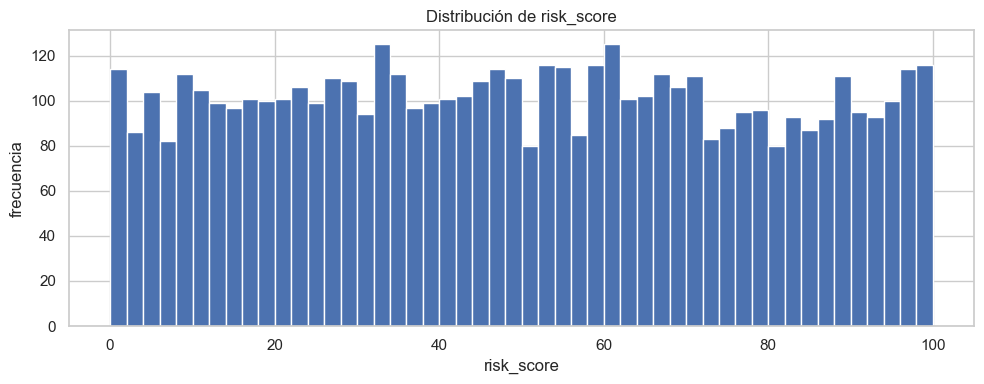

In [13]:
# Distribución de risk_score. Esperamos un score 0-100.
# Lo graficamos para ver la forma (uniforme? bimodal? sesgada?).
# Esa forma a veces revela cómo el generador sintético construyó el campo.
print(df_customers["risk_score"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df_customers["risk_score"].hist(bins=50, ax=ax, edgecolor="white")
ax.set_title("Distribución de risk_score")
ax.set_xlabel("risk_score")
ax.set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

In [14]:
# Fechas: rango temporal y validez post-parsing.
# Ahora SÍ usamos pd.to_datetime con errors='coerce': lo que no parsea
# se vuelve NaT (NULL para datetime). Ya entendimos los formatos en 3.2,
# así que pandas debería parsear ISO y compacto sin esfuerzo (los DD-MM
# y MM-DD requieren parsing manual, que hacemos en Silver).
df_customers["date_of_birth"] = pd.to_datetime(df_customers["date_of_birth"], errors="coerce")
df_customers["registration_date"] = pd.to_datetime(df_customers["registration_date"], errors="coerce")

print("date_of_birth:")
print(f"  min: {df_customers['date_of_birth'].min()}")
print(f"  max: {df_customers['date_of_birth'].max()}")
print(f"  nulls (incluye no-parseables): {df_customers['date_of_birth'].isna().sum()}")

print("\nregistration_date:")
print(f"  min: {df_customers['registration_date'].min()}")
print(f"  max: {df_customers['registration_date'].max()}")
print(f"  nulls (incluye no-parseables): {df_customers['registration_date'].isna().sum()}")

# Edad derivada para ver si hay valores absurdos (negativos, > 120)
today = pd.Timestamp.today()
df_customers["age"] = ((today - df_customers["date_of_birth"]).dt.days / 365.25).round(1)
print(f"\nEdad — describe:")
print(df_customers["age"].describe())

date_of_birth:
  min: 1950-05-08 00:00:00
  max: 2008-05-06 00:00:00
  nulls (incluye no-parseables): 916

registration_date:
  min: 2020-05-13 00:00:00
  max: 2026-04-20 00:00:00
  nulls (incluye no-parseables): 4797

Edad — describe:
count    4184.000000
mean       46.928633
std        16.869342
min        18.000000
25%        32.175000
50%        46.950000
75%        61.400000
max        76.000000
Name: age, dtype: float64


### 3.4 Duplicados de customer_id

`customer_id` debería ser la PK del nivel customer. Si está duplicada, todo el pipeline downstream falla (los tests `unique` en dbt rompen, los JOINs explotan filas, etc.). Tenemos que entender la magnitud y la naturaleza de los duplicados antes de elegir estrategia de dedup.

In [15]:
# Conteo simple de duplicados.
# duplicated() marca como True desde la segunda aparición en adelante,
# así que el conteo es 'cantidad de filas redundantes'.
dup_count = df_customers["customer_id"].duplicated().sum()
print(f"customer_id duplicados (filas redundantes): {dup_count}")

if dup_count > 0:
    print("\nMuestra de duplicados (mismos customer_id en filas distintas):")
    print(
        df_customers[df_customers["customer_id"].duplicated(keep=False)]
        .sort_values("customer_id")
        .head(10)
    )

customer_id duplicados (filas redundantes): 100

Muestra de duplicados (mismos customer_id en filas distintas):
       customer_id       first_name   last_name                                 email      phone_number date_of_birth gender nationality       city country  \
4903  CUST-0000060          Alfredo      Campos              alfredo.campos@yahoo.com  (+51) 7620990693           NaT  Other          PE      Piura      PE   
2805  CUST-0000060          Alfredo      Campos              alfredo.campos@yahoo.com  (+51) 7620990693           NaT  Other          PE      Piura      PE   
4934  CUST-0000064              Paz       Viana                 paz.viana@hotmail.com     +523285558095    1954-02-21      F          MX  Monterrey      MX   
2939  CUST-0000064              Paz       Viana                 paz.viana@hotmail.com     +523285558095    1954-02-21      F          MX  Monterrey      MX   
488   CUST-0000157  Thiago Ezequiel  Montesinos  thiago ezequiel.montesinos@gmail.com     +57

**Hallazgo Sección 3.4.** Hay 100 customer_id duplicados (98 que aparecen 2 veces + 1 que aparece 3 veces = 199 filas redundantes detectadas como `duplicated()`). Estos duplicados difieren entre sí únicamente en *casing/idioma de los campos categóricos* — son la misma persona registrada de formas distintas. La estrategia de dedup tiene que **canonicalizar primero** (lowercase + español→inglés) y **después** aplicar `ROW_NUMBER`, o si no los duplicados quedan como filas distintas para el window function.

---

## Sección 4 — Arrays nested: accounts, transactions, loans

Los tres arrays anidados son la fuente principal de cardinalidad del dataset. Cada customer tiene N accounts, M transactions, K loans. Acá:

1. **Aplanamos los arrays** preservando el `customer_id` parent (esto es lo que después hará Spark en escala).
2. **Inspeccionamos calidad** (nulls, categóricos, numéricos).
3. **Confirmamos la hipótesis crítica de duplicación**: los duplicados en arrays son 100% derivados de los duplicados en customers (no hay duplicación independiente).

In [16]:
# Aplanamos los tres arrays en DataFrames. El truco es preservar el
# customer_id parent en cada fila explotada, así podemos JOINear de vuelta.
# itertools.chain.from_iterable es más eficiente que list comprehension
# anidada cuando hay muchas filas (89k transactions vienen por acá).
accounts_rows = list(itertools.chain.from_iterable(
    [{**a, "customer_id": r["customer_id"]} for a in (r.get("accounts") or [])]
    for r in data
))
tx_rows = list(itertools.chain.from_iterable(
    [{**t, "customer_id": r["customer_id"]} for t in (r.get("transactions") or [])]
    for r in data
))
loans_rows = list(itertools.chain.from_iterable(
    [{**l, "customer_id": r["customer_id"]} for l in (r.get("loans") or [])]
    for r in data
))

df_accounts = pd.DataFrame(accounts_rows)
df_tx = pd.DataFrame(tx_rows)
df_loans = pd.DataFrame(loans_rows)

print(f"Accounts:     {len(df_accounts):>7,} filas  ({len(df_accounts)/len(data):.1f} por customer)")
print(f"Transactions: {len(df_tx):>7,} filas  ({len(df_tx)/len(data):.1f} por customer)")
print(f"Loans:        {len(df_loans):>7,} filas  ({len(df_loans)/len(data):.1f} por customer)")

# Distribución de cardinalidad por customer.
# Sirve para saber si hay customers con 0 accounts/loans (legítimo) o
# extremos (un customer con 50 accounts = posible bug).
print(f"\nCardinalidad por customer:")
counts = pd.DataFrame({
    "accounts":     [len(r.get("accounts") or [])     for r in data],
    "transactions": [len(r.get("transactions") or []) for r in data],
    "loans":        [len(r.get("loans") or [])        for r in data],
})
print(counts.describe().round(1))

Accounts:      17,870 filas  (3.5 por customer)
Transactions:  89,470 filas  (17.5 por customer)
Loans:          7,821 filas  (1.5 por customer)

Cardinalidad por customer:
       accounts  transactions   loans
count    5100.0        5100.0  5100.0
mean        3.5          17.5     1.5
std         1.1           7.5     1.1
min         2.0           5.0     0.0
25%         2.0          11.0     1.0
50%         4.0          17.0     2.0
75%         5.0          24.0     3.0
max         5.0          30.0     3.0


### 4.1 Auditoría de nulls en arrays

Mismo concepto que en customers: detectar nulls encubiertos. Encapsulamos la lógica en una función para reutilizarla en accounts, transactions, loans, credit_info y digital_engagement.

In [17]:
def null_audit(df, name):
    """Aplica normalize_nulls a las columnas object de un DataFrame
    y reporta nulls reales por columna.

    Retorna el DataFrame normalizado para que las celdas siguientes
    trabajen sobre datos limpios de nulls encubiertos.
    """
    print(f"\n{'='*60}")
    print(f"=== {name.upper()} (n={len(df):,}) ===")
    print(f"{'='*60}")
    print(f"Columnas: {df.columns.tolist()}")

    df_clean = df.copy()
    for col in df_clean.select_dtypes(include="object").columns:
        df_clean[col] = df_clean[col].map(normalize_nulls)

    nulls = df_clean.isna().sum()
    nulls_pct = (nulls / len(df_clean) * 100).round(2)
    out = (
        pd.DataFrame({"nulls": nulls, "pct": nulls_pct})
        .query("nulls > 0")
        .sort_values("nulls", ascending=False)
    )
    if len(out) > 0:
        print(f"\nNulls reales:\n{out}")
    else:
        print("\nSin nulls reales.")
    return df_clean

# Aplicamos a los tres arrays. Sobrescribimos los DataFrames
# para que las celdas siguientes trabajen sobre la versión limpia.
df_accounts = null_audit(df_accounts, "accounts")
df_tx       = null_audit(df_tx,       "transactions")
df_loans    = null_audit(df_loans,    "loans")


=== ACCOUNTS (n=17,870) ===
Columnas: ['account_id', 'account_type', 'currency', 'balance', 'credit_limit', 'interest_rate', 'opened_date', 'status', 'branch_code', 'customer_id']

Nulls reales:
              nulls    pct
credit_limit  13330  74.59

=== TRANSACTIONS (n=89,470) ===
Columnas: ['transaction_id', 'account_id', 'date', 'amount', 'currency', 'type', 'category', 'merchant', 'channel', 'status', 'description', 'customer_id']

Nulls reales:
             nulls    pct
description   9113  10.19
merchant      7380   8.25
category      4360   4.87

=== LOANS (n=7,821) ===
Columnas: ['loan_id', 'type', 'currency', 'principal', 'outstanding_balance', 'interest_rate', 'term_months', 'monthly_payment', 'start_date', 'end_date', 'status', 'days_past_due', 'collateral_type', 'customer_id']

Nulls reales:
                 nulls    pct
collateral_type   3727  47.65


### 4.2 Distribuciones categóricas en arrays

Confirmamos que el patrón "casing chaos + español/inglés" se repite en cada categórico de los arrays. Esto justifica escribir macros `normalize_*` específicas para cada uno en Silver dbt.

In [18]:
# Inspeccionamos las distribuciones categóricas de los 3 arrays.
# El head(25) es defensivo: si una columna tiene muchas variantes mal
# escritas (50+), las top 25 ya muestran el problema.
print("=" * 60)
print("ACCOUNTS")
print("=" * 60)
for col in ["account_type", "currency", "status"]:
    if col in df_accounts.columns:
        print(f"\n--- {col} ---")
        print(df_accounts[col].value_counts(dropna=False).head(25))

print("\n" + "=" * 60)
print("TRANSACTIONS")
print("=" * 60)
for col in ["type", "category", "channel", "status", "currency"]:
    if col in df_tx.columns:
        print(f"\n--- {col} ---")
        print(df_tx[col].value_counts(dropna=False).head(25))

print("\n" + "=" * 60)
print("LOANS")
print("=" * 60)
for col in ["type", "currency", "status", "collateral_type"]:
    if col in df_loans.columns:
        print(f"\n--- {col} ---")
        print(df_loans[col].value_counts(dropna=False).head(25))

ACCOUNTS

--- account_type ---
account_type
credit_card        4436
savings            4423
checking           4368
investment         4244
  investment         35
  credit_card        34
  checking           29
  savings            29
credit_card          27
 credit_card         27
 investment          26
investment           26
checking             23
  savings            23
savings              22
  investment         22
 savings             21
 checking            21
  checking           18
  credit_card        16
Name: count, dtype: int64

--- currency ---
currency
USD    8896
PEN    1341
COP    1322
MXN    1312
BRL    1294
UYU    1289
ARS    1271
CLP    1145
Name: count, dtype: int64

--- status ---
status
active       5121
frozen       5066
closed       5021
CLOSED        334
Closed        305
congelado     301
Active        296
cerrado       294
Frozen        289
ACTIVE        288
FROZEN        281
activo        274
Name: count, dtype: int64

TRANSACTIONS

--- type ---
type
ref

**Hallazgos clave Sección 4.2.**

- **`account_type`** tiene 4 valores reales (`savings`, `checking`, `investment`, `credit_card`) pero 20 variantes en bronze (cada uno multiplicado por whitespace antes/después). Un simple `trim()` resuelve todo. Esta limpieza es **sintáctica**, así que vive en Spark.
- **`account.status`** tiene 3 valores reales (`active`, `frozen`, `closed`) con 12 variantes (casing × traducciones). **Divergencia con la consigna**: la spec dice `active/inactive/suspended/closed` pero el dataset trae `active/frozen/closed`. Documentamos la divergencia y usamos el set real en `accepted_values`.
- **`currency`** es limpio: 8 valores LATAM coherentes (USD + ARS, BRL, CLP, COP, MXN, PEN, UYU). **Hallazgo de negocio**: ~50% de cuentas en USD, consistente con dolarización informal en la región (especialmente AR y UY).
- **`loans.collateral_type`** trae `None` como string en ~48% de loans. Es legítimo (loans unsecured no tienen colateral). Lo tratamos como `'unsecured'` semánticamente en Gold.

### 4.3 Duplicación en arrays

Verificamos la hipótesis fuerte: **los duplicados en `accounts`/`transactions`/`loans` son 100% derivados de los duplicados en `customers`**. Si esto se cumple, dedup en customers cascadea limpieza automáticamente a todos los arrays (no hace falta dedup independiente).

In [19]:
# Conteo bruto de duplicados por PK de cada array.
# Este es el dato que tenemos que explicar: ¿por qué hay duplicados?
print("Duplicados de account_id:     ", df_accounts["account_id"].duplicated().sum())
print("Duplicados de transaction_id: ", df_tx["transaction_id"].duplicated().sum())
print("Duplicados de loan_id:        ", df_loans["loan_id"].duplicated().sum())

Duplicados de account_id:      341
Duplicados de transaction_id:  1784
Duplicados de loan_id:         158


In [20]:
# Hipótesis: los duplicados en arrays vienen 100% de customers duplicados.
# Test: ¿coinciden los account_id duplicados con los customers duplicados?
dup_customer_ids = df_customers[
    df_customers["customer_id"].duplicated(keep=False)
]["customer_id"].unique()
print(f"Customers duplicados: {len(dup_customer_ids)}")

# Accounts que están en customers duplicados
acc_in_dup_cust = df_accounts[df_accounts["customer_id"].isin(dup_customer_ids)]
print(f"\nAccounts en customers duplicados: {len(acc_in_dup_cust)}")
print(f"Total duplicados de account_id:   {df_accounts['account_id'].duplicated().sum()}")

# ¿Todos los account_id duplicados pertenecen a customers duplicados?
dup_acc_ids = df_accounts[df_accounts["account_id"].duplicated(keep=False)]["account_id"].unique()
acc_dups_in_dup_cust = df_accounts[
    df_accounts["account_id"].isin(dup_acc_ids) &
    df_accounts["customer_id"].isin(dup_customer_ids)
]
total_acc_dups = len(df_accounts[df_accounts['account_id'].isin(dup_acc_ids)])
print(f"\nFilas con account_id duplicado Y customer duplicado: {len(acc_dups_in_dup_cust)}")
print(f"Filas con account_id duplicado en TOTAL:             {total_acc_dups}")
if len(acc_dups_in_dup_cust) == total_acc_dups:
    print("✓ Confirmado: 100% de account_id duplicados están en customers duplicados.")
else:
    print("⚠️ Hay account_id duplicados que NO están en customers duplicados.")

# Mismo análisis para transactions y loans
print("\n--- Transactions ---")
tx_in_dup_cust = df_tx[df_tx["customer_id"].isin(dup_customer_ids)]
print(f"Transactions en customers duplicados: {len(tx_in_dup_cust)}")
print(f"Total duplicados de transaction_id:   {df_tx['transaction_id'].duplicated().sum()}")

print("\n--- Loans ---")
loans_in_dup_cust = df_loans[df_loans["customer_id"].isin(dup_customer_ids)]
print(f"Loans en customers duplicados: {len(loans_in_dup_cust)}")
print(f"Total duplicados de loan_id:   {df_loans['loan_id'].duplicated().sum()}")

Customers duplicados: 99

Accounts en customers duplicados: 677
Total duplicados de account_id:   341

Filas con account_id duplicado Y customer duplicado: 677
Filas con account_id duplicado en TOTAL:             677
✓ Confirmado: 100% de account_id duplicados están en customers duplicados.

--- Transactions ---
Transactions en customers duplicados: 3538
Total duplicados de transaction_id:   1784

--- Loans ---
Loans en customers duplicados: 314
Total duplicados de loan_id:   158


In [21]:
# Diagnóstico fino: ¿hay customers con > 2 apariciones?
# Esto importa para elegir el algoritmo de dedup: si la mayoría aparece
# exactamente 2 veces, ROW_NUMBER funciona trivial. Si hay triples,
# necesitamos un criterio claro de cuál ganar (completitud + recencia).
counts = df_customers["customer_id"].value_counts()
multi = counts[counts > 1]
print(f"Customers con > 1 aparición: {len(multi)}")
print(f"\nDistribución de apariciones:")
print(multi.value_counts().sort_index())  # cuántos aparecen 2x, 3x, etc.

# Mostrar el caso de > 2 apariciones (suelen ser pocos pero ilustrativos)
if (multi > 2).any():
    triplicados = multi[multi > 2].index
    print(f"\nCustomer(s) con > 2 apariciones: {triplicados.tolist()}")
    print(df_customers[df_customers["customer_id"].isin(triplicados)].sort_values("customer_id"))

Customers con > 1 aparición: 99

Distribución de apariciones:
count
2    98
3     1
Name: count, dtype: int64

Customer(s) con > 2 apariciones: ['CUST-0004728']
       customer_id first_name last_name                        email   phone_number date_of_birth gender nationality       city country                                           address        lat  \
1722  CUST-0004728   Theodoro   Jiménez  theodoro.jiménez@icloud.com  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   
2701  CUST-0004728   tHEODORO   Jiménez  theodoro.jiménez@icloud.com  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   
3486  CUST-0004728   Theodoro   Jiménez  THEODORO.JIMÉNEZ@ICLOUD.COM  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   

            lon registration_date kyc_

**Hallazgo clave Sección 4.3.** Verificación aritmética: 98 customers × 2 apariciones + 1 customer × 3 apariciones = 199 filas detectadas como `duplicated()`, que coinciden con 100 customer_id distintos. Los duplicados en accounts/transactions/loans son derivados — todos pertenecen a customer_id duplicados. **Implicancia clave para el pipeline**: dedup a nivel customer + cascada por INNER JOIN limpia todos los arrays sin lógica adicional.

### 4.4 Auditoría de campos numéricos

Los campos numéricos en bronze pueden venir como strings con formatos sucios: con símbolos de moneda (`$1810568162.59`), con sufijos (`404393.03 USD`), con coma decimal latina (`191286,14`), o como mezcla. Antes de coercitar con `pd.to_numeric`, vemos exactamente cuántos casos hay y de qué tipo.

In [22]:
def audit_numeric_field(df, col):
    """Para una columna que debería ser numérica, cuenta cuántos valores
    son strings (vs int/float). Si hay strings, muestra los más frecuentes
    para entender qué formato de suciedad tenemos."""
    if col not in df.columns:
        return
    types_count = df[col].map(lambda v: type(v).__name__).value_counts()
    print(f"\n--- {col} ---")
    print(f"Tipos encontrados:\n{types_count}")

    # Si hay strings, mostrarmos ejemplos para entender el patrón
    str_mask = df[col].map(lambda v: isinstance(v, str))
    if str_mask.any():
        print(f"\nMuestra de strings ({str_mask.sum()} total):")
        print(df.loc[str_mask, col].value_counts().head(15))

print("=" * 60)
print("ACCOUNTS — campos numéricos")
print("=" * 60)
for col in ["balance", "credit_limit", "interest_rate"]:
    audit_numeric_field(df_accounts, col)

print("\n" + "=" * 60)
print("TRANSACTIONS — campos numéricos")
print("=" * 60)
for col in ["amount"]:
    audit_numeric_field(df_tx, col)

print("\n" + "=" * 60)
print("LOANS — campos numéricos")
print("=" * 60)
for col in ["principal", "outstanding_balance", "interest_rate",
            "term_months", "monthly_payment", "days_past_due"]:
    audit_numeric_field(df_loans, col)

ACCOUNTS — campos numéricos

--- balance ---
Tipos encontrados:
balance
float    17377
str        493
Name: count, dtype: int64

Muestra de strings (493 total):
balance
424926.82         2
9618.56           2
794739.12         2
404393.03 USD     2
$1810568162.59    2
427627.0          2
135584.29         2
191286,14         1
143184.51 USD     1
404640.21 USD     1
319165.74         1
$1771405482.12    1
449001,65         1
120656,74         1
397859,06         1
Name: count, dtype: int64

--- credit_limit ---
Tipos encontrados:
credit_limit
float    17870
Name: count, dtype: int64

--- interest_rate ---
Tipos encontrados:
interest_rate
float    17870
Name: count, dtype: int64

TRANSACTIONS — campos numéricos

--- amount ---
Tipos encontrados:
amount
float    86811
str       2659
Name: count, dtype: int64

Muestra de strings (2659 total):
amount
38222.59         2
17559.52 USD     2
$236384.75       2
49434,97         2
37394,68         2
48342.52         2
28058,7          2
$45360.5

Vemos que ~3% de los valores numéricos llegan como strings sucios. Los formatos detectados:

- **Limpios:** `"424926.82"` — cast directo.
- **Latinos:** `"191286,14"` — reemplazar `,` por `.`.
- **Con símbolo:** `"$1810568162.59"` — strip de `$`.
- **Con sufijo de moneda:** `"404393.03 USD"` — regex para quitar el sufijo.

Cualquier `pd.to_numeric` sin pre-procesamiento NULL-ea estos casos silenciosamente, lo cual subestima el dataset. La solución en Spark es una función `parse_money` con limpieza en cascada (regex + manejo de formato latino), que mostramos abajo como referencia.

In [23]:
def to_numeric_safe(series):
    """Convierte una Series a numérica retornando tanto el resultado
    como un contador de strings invalidos (que pasaron a NaN).

    Útil para saber cuánto perdiste en la conversión.
    pd.to_numeric con errors='coerce' lo hace silenciosamente; esta
    función expone la cuenta.
    """
    converted = pd.to_numeric(series, errors="coerce")
    was_not_null = series.notna()
    became_null  = converted.isna()
    invalid = (was_not_null & became_null).sum()  # eran no-null pero no parsearon
    return converted, invalid

print("=== ACCOUNTS — numéricos (post-coerción) ===")
acc_num = df_accounts.copy()
for col in ["balance", "credit_limit", "interest_rate"]:
    if col in acc_num.columns:
        acc_num[col], invalid = to_numeric_safe(acc_num[col])
        if invalid > 0:
            print(f"  {col}: {invalid} strings no parseables → NaN")

print("\n", acc_num[["balance", "credit_limit", "interest_rate"]].describe().round(2), sep="")

# Sanity checks: valores que estadísticamente nos llaman la atención
print(f"\nbalance < 0:        {(acc_num['balance'] < 0).sum()} (esperable en credit_card)")
print(f"interest_rate < 0:  {(acc_num['interest_rate'] < 0).sum()}")
print(f"interest_rate > 100: {(acc_num['interest_rate'] > 100).sum()}")

print("\n=== TRANSACTIONS — amounts ===")
tx_num = df_tx.copy()
tx_num["amount"], invalid = to_numeric_safe(tx_num["amount"])
if invalid > 0:
    print(f"  amount: {invalid} strings no parseables → NaN")
print(tx_num["amount"].describe().round(2))
print(f"amount < 0:  {(tx_num['amount'] < 0).sum()}")
print(f"amount == 0: {(tx_num['amount'] == 0).sum()}")

print("\n=== LOANS — numéricos (post-coerción) ===")
loans_num = df_loans.copy()
loan_cols = ["principal", "outstanding_balance", "interest_rate",
             "term_months", "monthly_payment", "days_past_due"]
for col in loan_cols:
    if col in loans_num.columns:
        loans_num[col], invalid = to_numeric_safe(loans_num[col])
        if invalid > 0:
            print(f"  {col}: {invalid} strings no parseables → NaN")
print(loans_num[loan_cols].describe().round(2))

# Invariantes de loans que conviene validar
print(f"\noutstanding_balance > principal: {(loans_num['outstanding_balance'] > loans_num['principal']).sum()}")
print(f"days_past_due < 0:               {(loans_num['days_past_due'] < 0).sum()}")
print(f"principal < 0:                   {(loans_num['principal'] < 0).sum()}")

=== ACCOUNTS — numéricos (post-coerción) ===
  balance: 369 strings no parseables → NaN

            balance  credit_limit  interest_rate
count  1.750100e+04  4.540000e+03       17870.00
mean   1.082106e+08  2.168415e+07          12.69
std    3.120016e+08  6.366832e+07           7.09
min    2.378500e+02  1.053720e+03           0.50
25%    2.291670e+05  4.571259e+04           6.51
50%    4.603146e+05  9.347612e+04          12.60
75%    8.885091e+06  1.767089e+06          18.86
max    1.999231e+09  3.981051e+08          25.00

balance < 0:        0 (esperable en credit_card)
interest_rate < 0:  0
interest_rate > 100: 0

=== TRANSACTIONS — amounts ===
  amount: 1941 strings no parseables → NaN
count    8.752900e+04
mean     1.125374e+07
std      3.150606e+07
min      1.890000e+00
25%      2.397219e+04
50%      4.831629e+04
75%      1.162502e+06
max      1.999953e+08
Name: amount, dtype: float64
amount < 0:  0
amount == 0: 0

=== LOANS — numéricos (post-coerción) ===
  principal: 171 strin

**Referencia para Silver (PySpark):** acá va la función `parse_money` que después se usa en los scripts de Spark para parsear los strings monetarios sucios. La incluimos en el notebook como prueba de concepto — el código real vive en `spark/utils.py`.

In [24]:
# Referencia de la función parse_money que después vive en spark/utils.py.
# Esta versión es ilustrativa; en Spark se usa pyspark.sql.functions (F).
#
# Cascada de limpieza:
#   1. Quitar sufijo de moneda " USD", " ARS", etc.
#   2. Quitar símbolos $, €, £.
#   3. Detectar formato latino "1.234,56" (puntos como miles, coma decimal)
#      y convertirlo a notación estándar.
#   4. Cast a double; lo que falle → NULL.
#
# El orden importa: si quitamos comas antes de detectar el patrón latino,
# perdemos la señal que distingue "1.234,56" (latino) de "1234.56" (estándar).
EXAMPLE_PARSE_MONEY = '''
from pyspark.sql import functions as F

def parse_money(col):
    cleaned = F.regexp_replace(
        col.cast("string"),
        r"\\s+(USD|EUR|ARS|BRL|CLP|COP|MXN|PEN|UYU)$",
        ""
    )
    cleaned = F.regexp_replace(cleaned, r"[\\$€£]", "")
    cleaned = F.when(
        cleaned.rlike(r"^\\d{1,3}(\\.\\d{3})+,\\d+$"),
        F.regexp_replace(F.regexp_replace(cleaned, r"\\.", ""), r",", ".")
    ).otherwise(
        F.regexp_replace(cleaned, r",", ".")
    )
    return cleaned.cast("double")
'''

print(EXAMPLE_PARSE_MONEY)


from pyspark.sql import functions as F

def parse_money(col):
    cleaned = F.regexp_replace(
        col.cast("string"),
        r"\s+(USD|EUR|ARS|BRL|CLP|COP|MXN|PEN|UYU)$",
        ""
    )
    cleaned = F.regexp_replace(cleaned, r"[\$€£]", "")
    cleaned = F.when(
        cleaned.rlike(r"^\d{1,3}(\.\d{3})+,\d+$"),
        F.regexp_replace(F.regexp_replace(cleaned, r"\.", ""), r",", ".")
    ).otherwise(
        F.regexp_replace(cleaned, r",", ".")
    )
    return cleaned.cast("double")



---

## Sección 5 — Objects nested: credit_info, digital_engagement

Estos dos no son arrays (no cambian la cardinalidad) — son objetos a nivel customer con sub-campos. Por eso van a vivir como dimensiones separadas en Silver (`dim_credit_info`, `dim_digital_engagement`), no se aplanan con Spark sino con dbt usando `jsonb` operators de Postgres directamente.

In [25]:
# Aplanamos credit_info y digital_engagement en DataFrames separados,
# preservando customer_id. Cada record contribuye una sola fila (cardinalidad
# 1:1 con customer), a diferencia de los arrays.
credit_rows = [
    {**(r.get("credit_info") or {}), "customer_id": r["customer_id"]}
    for r in data
]
digital_rows = [
    {**(r.get("digital_engagement") or {}), "customer_id": r["customer_id"]}
    for r in data
]

df_credit  = pd.DataFrame(credit_rows)
df_digital = pd.DataFrame(digital_rows)

print(f"credit_info:        {df_credit.shape}")
print(f"digital_engagement: {df_digital.shape}")
print(f"\nColumnas credit_info:\n  {df_credit.columns.tolist()}")
print(f"\nColumnas digital_engagement:\n  {df_digital.columns.tolist()}")

credit_info:        (5100, 11)
digital_engagement: (5100, 8)

Columnas credit_info:
  ['credit_score', 'currency', 'utilization_pct', 'total_limit', 'total_used', 'num_credit_accounts', 'oldest_account_age_months', 'late_payments_12m', 'inquiries_6m', 'bankruptcy_flag', 'customer_id']

Columnas digital_engagement:
  ['mobile_app_registered', 'web_banking_registered', 'last_login_date', 'avg_monthly_logins', 'preferred_channel', 'push_notifications', 'paperless_statements', 'customer_id']


In [26]:
# Auditoría de nulls reusando la función null_audit definida en 4.1.
df_credit  = null_audit(df_credit,  "credit_info")
df_digital = null_audit(df_digital, "digital_engagement")


=== CREDIT_INFO (n=5,100) ===
Columnas: ['credit_score', 'currency', 'utilization_pct', 'total_limit', 'total_used', 'num_credit_accounts', 'oldest_account_age_months', 'late_payments_12m', 'inquiries_6m', 'bankruptcy_flag', 'customer_id']

Sin nulls reales.

=== DIGITAL_ENGAGEMENT (n=5,100) ===
Columnas: ['mobile_app_registered', 'web_banking_registered', 'last_login_date', 'avg_monthly_logins', 'preferred_channel', 'push_notifications', 'paperless_statements', 'customer_id']

Nulls reales:
                    nulls   pct
avg_monthly_logins    377  7.39


### 5.1 Validaciones numéricas en credit_info

Aplicamos sanity checks específicos a los campos numéricos: el `credit_score` debe estar entre 300 y 850 (rango FICO), `utilization_pct` debe estar entre 0 y 100 (o > 100 en casos legítimos de overlimit), `late_payments_12m` debe estar entre 0 y 12 por definición, etc.

In [27]:
print("=== credit_info — describe ===")
# Forzamos coerción numérica primero por si hay strings sucios
# (mismo problema que en la sección 4.4 con loans/accounts).
for col in ["credit_score", "utilization_pct", "total_limit", "total_used",
            "num_credit_accounts", "oldest_account_age_months",
            "late_payments_12m", "inquiries_6m"]:
    if col in df_credit.columns:
        df_credit[col] = pd.to_numeric(df_credit[col], errors="coerce")

print(df_credit[[
    "credit_score", "utilization_pct", "total_limit", "total_used",
    "num_credit_accounts", "oldest_account_age_months",
    "late_payments_12m", "inquiries_6m"
]].describe().round(2))

print("\n=== Validaciones de rango (sanity checks) ===")

# credit_score FICO está definido en [300, 850]. Fuera de rango = corrupto.
out_of_range = ((df_credit['credit_score'] < 300) | (df_credit['credit_score'] > 850)).sum()
print(f"credit_score fuera de [300, 850]:            {out_of_range}")

# utilization_pct fuera de [0, 100]: imposible (negativos) o overlimit (>100, legítimo)
neg_util = (df_credit['utilization_pct'] < 0).sum()
over_util = (df_credit['utilization_pct'] > 100).sum()
print(f"utilization_pct < 0 (imposible):              {neg_util}")
print(f"utilization_pct > 100 (overlimit, legítimo): {over_util}")

# total_used > total_limit indica overlimit; complementa a utilization > 100
print(f"total_used > total_limit:                    {(df_credit['total_used'] > df_credit['total_limit']).sum()}")

# late_payments_12m por definición está acotada en [0, 12]
print(f"late_payments_12m < 0:                       {(df_credit['late_payments_12m'] < 0).sum()}")
print(f"late_payments_12m > 12 (imposible):          {(df_credit['late_payments_12m'] > 12).sum()}")

=== credit_info — describe ===
       credit_score  utilization_pct   total_limit    total_used  num_credit_accounts  oldest_account_age_months  late_payments_12m  inquiries_6m
count       5100.00          5081.00  4.977000e+03  4.983000e+03              5100.00                    5100.00            5100.00       5100.00
mean       28580.62            50.03  8.649282e+07  4.179899e+07                 5.49                     182.93               5.93          5.01
std       165009.08            28.73  1.642058e+08  9.416112e+07                 2.88                     103.33               3.74          3.16
min          -99.00             0.00  1.889446e+04  2.616000e+01                 1.00                       6.00               0.00          0.00
25%          417.00            24.92  6.326747e+05  2.639954e+05                 3.00                      93.00               3.00          2.00
50%          567.00            50.55  3.475492e+06  1.624914e+06                 5.00        

**Hallazgo crítico Sección 5.1.** El `credit_score` tiene **~10% de valores corruptos** (fuera del rango FICO 300-850, con valores absurdos como `-99` o `999999`). Esto afecta directamente la business question Q6 ("distribución de credit score por país"). Estrategia en Silver: el patrón `raw + flag + validated` — preservar el valor original como `credit_score_raw`, exponer un boolean `is_credit_score_valid`, y proveer una versión NULL-eada `credit_score` para usar en agregaciones.

In [28]:
# Atributos categóricos en credit_info
print("--- credit_info.currency ---")
print(df_credit["currency"].value_counts(dropna=False))

# bankruptcy_flag debería ser boolean. Inspeccionamos qué llega realmente.
# Spoiler: el generador mezcla bool/string/int en columnas que deberían
# ser puros booleans, y digital_engagement tiene peor mezcla todavía.
print("\n--- credit_info.bankruptcy_flag ---")
print(df_credit["bankruptcy_flag"].value_counts(dropna=False))
print(f"Tipo detectado por pandas: {df_credit['bankruptcy_flag'].dtype}")

--- credit_info.currency ---
currency
BRL    756
PEN    756
UYU    744
MXN    732
ARS    722
COP    715
CLP    675
Name: count, dtype: int64

--- credit_info.bankruptcy_flag ---
bankruptcy_flag
False    2423
True     2297
true      105
false     102
N          87
Y          86
Name: count, dtype: int64
Tipo detectado por pandas: object


### 5.2 Booleans mezclados en digital_engagement

Las flags booleanas son otro foco típico de problemas con datasets sintéticos. Acá inspeccionamos qué llega realmente en los 4 campos boolean del objeto `digital_engagement` (mobile_app_registered, web_banking_registered, push_notifications, paperless_statements).

In [29]:
# preferred_channel — categórico
# Hallazgo crítico: 'phone' aparece en preferred_channel pero NO en
# transactions.channel. Son dos universos distintos: NO unificar en una
# sola dim_channel. preferred_channel del customer != channel de la tx.
print("--- digital_engagement.preferred_channel ---")
print(df_digital["preferred_channel"].value_counts(dropna=False).head(20))

print("\n--- Boolean fields ---")
for col in ["mobile_app_registered", "web_banking_registered",
            "push_notifications", "paperless_statements"]:
    if col in df_digital.columns:
        print(f"\n{col}:")
        print(df_digital[col].value_counts(dropna=False))
        print(f"  dtype: {df_digital[col].dtype}")

print("\n--- avg_monthly_logins ---")
df_digital["avg_monthly_logins"] = pd.to_numeric(df_digital["avg_monthly_logins"], errors="coerce")
print(df_digital["avg_monthly_logins"].describe().round(2))

print("\n--- last_login_date — formato ---")
raw_logins = pd.Series([
    (r.get("digital_engagement") or {}).get("last_login_date")
    for r in data
])
print("Sample:", raw_logins.dropna().sample(10, random_state=42).tolist())
print(f"Nulls (incluye tokens): {raw_logins.isna().sum() + raw_logins.map(lambda s: isinstance(s, str) and s.strip().lower() in NULL_TOKENS).sum()}")

--- digital_engagement.preferred_channel ---
preferred_channel
mobile    1083
atm       1023
branch    1020
phone      988
web        986
Name: count, dtype: int64

--- Boolean fields ---

mobile_app_registered:
mobile_app_registered
False    2591
True     2509
Name: count, dtype: int64
  dtype: bool

web_banking_registered:
web_banking_registered
False    2590
True     2510
Name: count, dtype: int64
  dtype: bool

push_notifications:
push_notifications
True     2389
False    2327
yes       114
false      95
no         90
true       85
Name: count, dtype: int64
  dtype: object

paperless_statements:
paperless_statements
True     2368
False    2339
false     107
true       98
no         97
si         91
Name: count, dtype: int64
  dtype: object

--- avg_monthly_logins ---
count    4723.00
mean       30.04
std        17.38
min         0.00
25%        15.00
50%        30.00
75%        45.00
max        60.00
Name: avg_monthly_logins, dtype: float64

--- last_login_date — formato ---
Sample

**Hallazgo Sección 5.2.** Los 4 booleans en `digital_engagement` traen variantes mezcladas:

- bool reales (`True`/`False`)
- strings inglés (`"true"`/`"false"`)
- letras (`"Y"`/`"N"`)
- español (`"si"`)
- numeric (`0`/`1`)

Esto justifica escribir una macro `safe_cast_boolean()` en dbt análoga a `safe_cast_numeric()`, que acepte el catálogo completo de variantes y NULL-ee el resto.

**Observación importante sobre `preferred_channel`.** El campo expone `phone` como uno de los valores, mientras que `transactions.channel` tiene `pos` en su lugar. Son **dos universos distintos** — no crear una `dim_channel` única que mezcle ambos.

---

## Sección 6 — Decisiones derivadas del EDA

El EDA produjo una serie de hallazgos concretos que se traducen directamente en decisiones de modelado. Cada uno está documentado en `docs/decisions.md` con su rationale completo; acá listamos el mapeo entre **hallazgo** → **decisión** para fijar el cierre del Día 1.

### 6.1 Calidad de datos

| Hallazgo | Decisión |
|---|---|
| 5.100 records (consigna pedía ~5.000) | Volumen confirmado, sin sub/sobre-load |
| Schema top-level uniforme (24 keys) | Sin lógica defensiva para campos faltantes a nivel root |
| Casing chaos + traducciones ES↔EN en todos los categóricos | Una macro `normalize_*` por campo en Silver dbt (lowercase + mapping ES→EN) |
| Nulls codificados como strings (`"null"`, `"N/A"`, `"None"`, `""`) | Función `safe_cast_*` en Spark/dbt que NULL-ea estos 5 tokens antes de castear |
| 4 formatos de fecha coexistentes, separador desambigua orden | Cascada de parsing con `coalesce` en orden ISO → compacto → MM-DD-YYYY → DD/MM/YYYY |
| ~3% numéricos como strings con $ / sufijos / formato latino | Función `parse_money` en Spark con regex + manejo de formato latino |
| Outliers extremos en montos (~$2 mil millones) | No descartar (legítimo en private_banking); usar mediana en KPIs sensibles |
| 10% credit_score fuera de [300, 850] | Patrón raw + flag + validated en `dim_credit_info` |
| Booleans con 5 representaciones distintas | Macro `safe_cast_boolean` con tabla de mapeo |

### 6.2 Categóricos

| Hallazgo | Decisión |
|---|---|
| `customer.status` = `active/inactive/suspended/closed` (4 canónicos coinciden con spec, 20 variantes superficiales) | Macro `normalize_customer_status` lowercase + ES→EN |
| `account.status` = `active/frozen/closed` (diverge de spec) | Documentar divergencia; `accepted_values` con el set REAL |
| `customer_segment` = `retail/premium/sme/private_banking` (4 valores, 16 variantes) | Macro `normalize_customer_segment` lowercase + ES→EN |
| Currency con 8 valores LATAM coherentes | No requiere normalización |
| ~50% cuentas en USD | Hallazgo de negocio (dolarización); guiar decisiones de Gold sobre conversión USD |
| `collateral_type = "None"` en 48% | Map a NULL en Silver; map a `'unsecured'` en Gold |
| `preferred_channel` ≠ `transactions.channel` | NO crear `dim_channel` única; mantener separados |

### 6.3 Duplicación

| Hallazgo | Decisión |
|---|---|
| 98 customer_id × 2 + 1 customer_id × 3 = 100 customers duplicados | Dedup en customers con `ROW_NUMBER` ordenando por (completitud desc, registration_date desc) |
| 100% duplicados en arrays derivados de duplicados en customers | Dedup customers cascadea limpieza por INNER JOIN a todos los arrays |
| Duplicados difieren en casing/idioma de categóricos | **Canonicalizar PRIMERO**, después dedup (el orden importa) |

### 6.4 Tratamiento de nulls reales

Una vez normalizados los nulls encubiertos, los reales que quedan tienen distribuciones específicas que requieren decisión campo por campo. La tabla completa vive en `docs/decisions.md §6`; los más relevantes:

- `relationship_manager` (9,9%), `gender` (5,4%): pass-through NULL (revisado Día 6, no se implementaron los imputes originalmente planeados).
- `accounts.credit_limit` (74,6%): legítimo, solo `credit_card` lo tiene.
- `loans.collateral_type` (47,7%): legítimo, unsecured loans.
- `credit_score` (~10% corrupto): patrón raw + flag + validated.

---

## Cierre

Este EDA cubre todo lo que necesitamos para empezar a diseñar el pipeline:

1. **Schema y volumen** validados contra la consigna.
2. **Calidad** mapeada por tipo de problema (categóricos, nulls encubiertos, numéricos sucios, fechas multi-formato, booleans mezclados).
3. **Duplicación** entendida y con estrategia clara (canonicalizar → dedup customers → cascada por JOIN).
4. **Decisiones documentadas** en `docs/decisions.md` con rationale completo.

El siguiente paso (Día 2) es construir la capa Bronze: DAG de Airflow que descarga el JSON de S3 y lo persiste en Postgres como `jsonb` con metadata de auditoría (`load_id`, `load_timestamp`).